<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [18]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [19]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head(2)


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


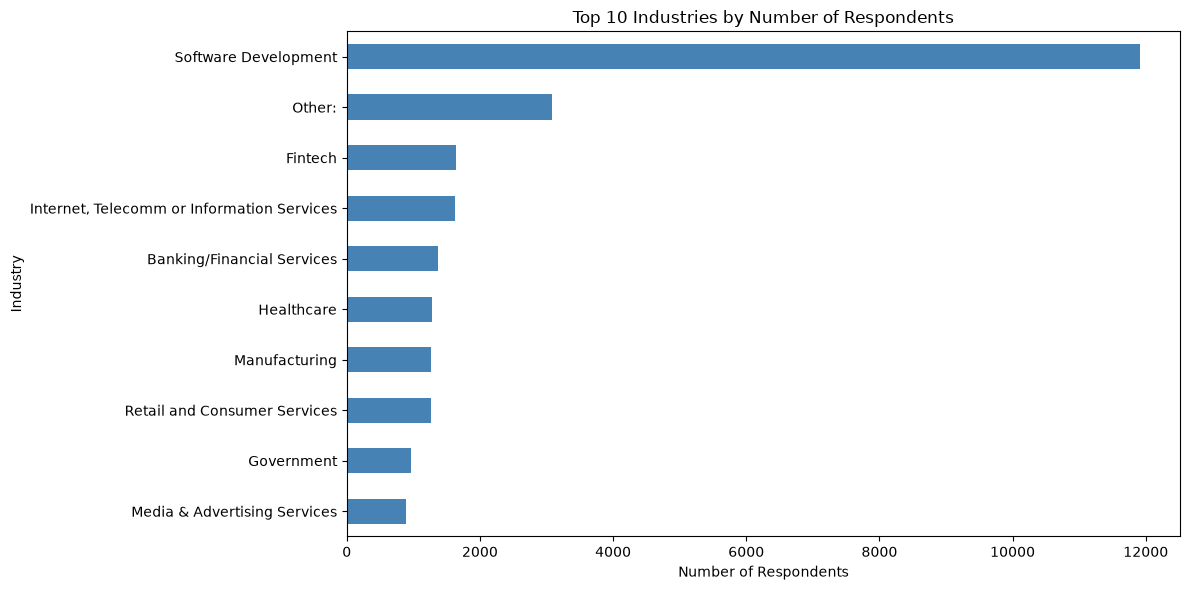

In [20]:
##Write your code here
industry_counts = df['Industry'].value_counts().head(10)

plt.figure(figsize=(12, 6))
industry_counts.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Industries by Number of Respondents')
plt.xlabel('Number of Respondents')
plt.ylabel('Industry')

plt.tight_layout()
plt.show()

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [21]:
df["ConvertedCompYearly"].value_counts()

ConvertedCompYearly
64444.0     321
53703.0     308
75184.0     230
85925.0     226
107406.0    208
           ... 
152615.0      1
4364.0        1
15637.0       1
9711.0        1
116844.0      1
Name: count, Length: 6113, dtype: int64

In [22]:
df["ConvertedCompYearly"].isnull().sum()

np.int64(42002)

In [23]:
##Write your code here
CCY_df = df["ConvertedCompYearly"].dropna()
print("Basic statistics for ConvertedCompYearly")
CCY_df.describe().to_frame()

Basic statistics for ConvertedCompYearly


,ConvertedCompYearly
count,2.343500e+04
mean,8.615529e+04
std,1.867570e+05
min,1.000000e+00
25%,3.271200e+04
50%,6.500000e+04
75%,1.079715e+05
max,1.625660e+07


In [24]:
ccy_mean =CCY_df.mean()
ccy_median =CCY_df.median()
ccy_std =CCY_df.std()
threshold = ccy_mean + 3* ccy_std

print(f"Mean: {ccy_mean:.2f}")
print(f"Median: {ccy_median:.2f}")
print(f"Standard deviation: {ccy_std:.2f}")
print(f"Threshold (mean + 3*std): {threshold:.2f}")

high_outliers = df[df['ConvertedCompYearly'] > threshold]
print(f"Respondents whose annual compensation exceeds this threshold: {len(high_outliers)}")
high_outliers[['ConvertedCompYearly', 'Industry', 'Country']].head(10)

Mean: 86155.29
Median: 65000.00
Standard deviation: 186756.97
Threshold (mean + 3*std): 646426.21
Respondents whose annual compensation exceeds this threshold: 89


,ConvertedCompYearly,Industry,Country
529,650000.0,Software Development,United States of America
828,1000000.0,Retail and Consumer Services,United States of America
1932,945000.0,Insurance,United States of America
2171,750000.0,Banking/Financial Services,United States of America
2187,2000000.0,NaN,Gabon
2316,1000000.0,Software Development,United States of America
2592,800000.0,Software Development,United States of America
3024,1302817.0,NaN,Kazakhstan
5934,1031099.0,NaN,Germany
6735,650000.0,Other:,United States of America


<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


Q1: 32712.0
Q3: 107971.5
IQR: 75259.5
Lower Bound: -80177.25
Upper Bound: 220860.75
Number of outliers: 978


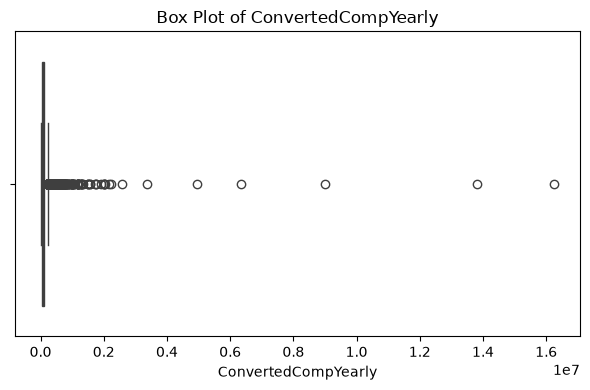

In [25]:
##Write your code here
# Select a numeric column
col = df['ConvertedCompYearly'].dropna()

# Calculate quartiles
Q1 = col.quantile(0.25)
Q3 = col.quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")


outlier_count = ((col < lower_bound) | (col > upper_bound)).sum()
print(f"Number of outliers: {outlier_count}")

plt.figure(figsize=(6, 4))
sns.boxplot(x=col)
plt.title('Box Plot of ConvertedCompYearly')
plt.xlabel('ConvertedCompYearly')
plt.tight_layout()
plt.show()

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [26]:
##Write your code here
df_new = df[(df['ConvertedCompYearly'].isna()) | ((df['ConvertedCompYearly'] >= lower_bound) 
                                                & (df['ConvertedCompYearly'] <= upper_bound))].copy()

print("Cleaned DataFrame shape: ", df_new.shape)
print("Original DataFrame shape: ", df.shape)
print("Total removed rows: ", df.shape[0] - df_new.shape[0])
df_new.head(10)

Cleaned DataFrame shape:  (64459, 114)
Original DataFrame shape:  (65437, 114)
Total removed rows:  978


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN
5,6,I code primarily as a hobby,Under 18 years old,"Student, full-time",NaN,Apples,NaN,Primary/elementary school,"School (i.e., University, College, etc);Online...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
6,7,"I am not primarily a developer, but I write co...",35-44 years old,"Employed, full-time",Remote,Apples,I don’t code outside of work,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Stack Overflow;Written...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Neither easy nor difficult,NaN,NaN
7,8,I am learning to code,18-24 years old,"Student, full-time;Not employed, but looking f...",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Video-based Online Cou...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Difficult,NaN,NaN
8,9,I code primarily as a hobby,45-54 years old,"Employed, full-time",In-person,Apples,Hobby,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Books / Physical media;Other online resources ...,Stack Overflow;Written-based Online Courses,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor difficult,NaN,NaN
9,10,I am a developer by profession,35-44 years old,"Independent contractor, freelancer, or self-em...",Remote,Apples,Bootstrapping a business,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",On the job training;Other online resources (e....,Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN


<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


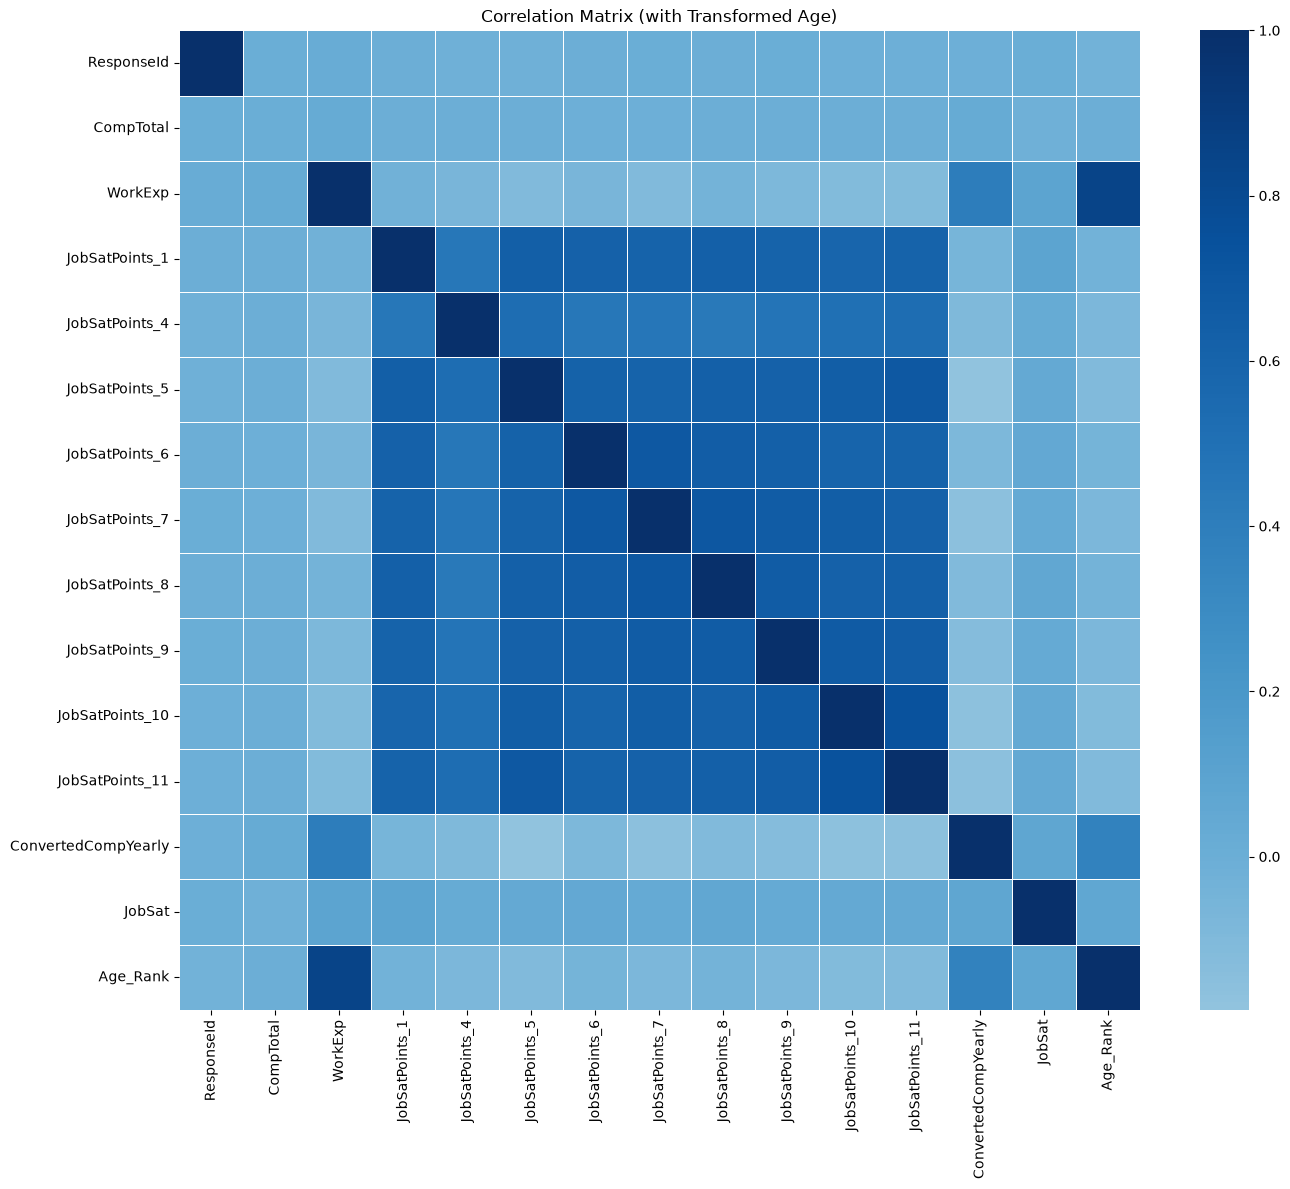

In [17]:
##Write your code here
def years_to_numeric(value):
    if pd.isna(value):
        return np.nan
    if value == 'Less than 1 year':
        return 0.5
    if value == 'More than 50 years':
        return 51
    return float(value)

age_order = {'Under 18 years old': 17,
             '18-24 years old': 21,
             '25-34 years old': 30,
             '35-44 years old': 40,
             '45-54 years old': 50,
             '55-64 years old': 60,
             '65 years or older': 70
            }

df_new['Age_Rank'] = df_new['Age'].map(age_order)

num_columns = df_new.select_dtypes(include='number').columns.tolist()
corr_matrix = df_new[num_columns].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap='Blues', center=0, linewidths=0.5)
plt.title('Correlation Matrix (with Transformed Age)')
plt.tight_layout()
plt.show()

corr_matrix['Age_Numeric'].dropna().sort_values(ascending=False).head(10)

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
